In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, confusion_matrix)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/creditcard_features.csv')

feature_cols = [c for c in df.columns 
                if c not in ['Class', 'Time', 'Amount']]

X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,}")
print(f"Test set:     {X_test.shape[0]:,} rows | Fraud: {y_test.sum():,}")
print(f"Features:     {len(feature_cols)}")
print(f"\nFraud rate in train: {y_train.mean():.4%}")
print(f"Fraud rate in test:  {y_test.mean():.4%}")

Training set: 227,845 rows | Fraud: 394
Test set:     56,962 rows | Fraud: 98
Features:     36

Fraud rate in train: 0.1729%
Fraud rate in test:  0.1720%


In [3]:
# Apply SMOTE — only on training data, never test data
smote = SMOTE(random_state=42, sampling_strategy=0.1)  # 10% fraud ratio
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_bal.value_counts().to_dict()}")
print(f"New fraud rate: {y_train_bal.mean():.2%}")

# Logistic Regression baseline
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)

lr_auc = roc_auc_score(y_test, lr_proba)
lr_ap = average_precision_score(y_test, lr_proba)

print(f"\nLogistic Regression Results:")
print(f"  ROC-AUC:           {lr_auc:.4f}")
print(f"  Avg Precision:     {lr_ap:.4f}  ← key metric for fraud")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Fraud']))

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 22745}
New fraud rate: 9.09%

Training Logistic Regression...

Logistic Regression Results:
  ROC-AUC:           0.9667
  Avg Precision:     0.7411  ← key metric for fraud

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



In [4]:
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train_bal, y_train_bal)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_ap = average_precision_score(y_test, xgb_proba)

print(f"XGBoost Results:")
print(f"  ROC-AUC:           {xgb_auc:.4f}")
print(f"  Avg Precision:     {xgb_ap:.4f}  ← key metric for fraud")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))

print(f"\n=== COMPARISON ===")
print(f"{'Metric':<20} {'Log. Reg':>10} {'XGBoost':>10} {'Improvement':>12}")
print("-" * 55)
for metric, lr_val, xgb_val in [
    ('ROC-AUC', lr_auc, xgb_auc),
    ('Avg Precision', lr_ap, xgb_ap)
]:
    imp = ((xgb_val - lr_val) / lr_val) * 100
    print(f"{metric:<20} {lr_val:>10.4f} {xgb_val:>10.4f} {imp:>+11.1f}%")

Training XGBoost...
XGBoost Results:
  ROC-AUC:           0.9755
  Avg Precision:     0.8525  ← key metric for fraud

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.41      0.88      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.78     56962
weighted avg       1.00      1.00      1.00     56962


=== COMPARISON ===
Metric                 Log. Reg    XGBoost  Improvement
-------------------------------------------------------
ROC-AUC                  0.9667     0.9755        +0.9%
Avg Precision            0.7411     0.8525       +15.0%


Calculating SHAP values (this takes ~2 mins)...


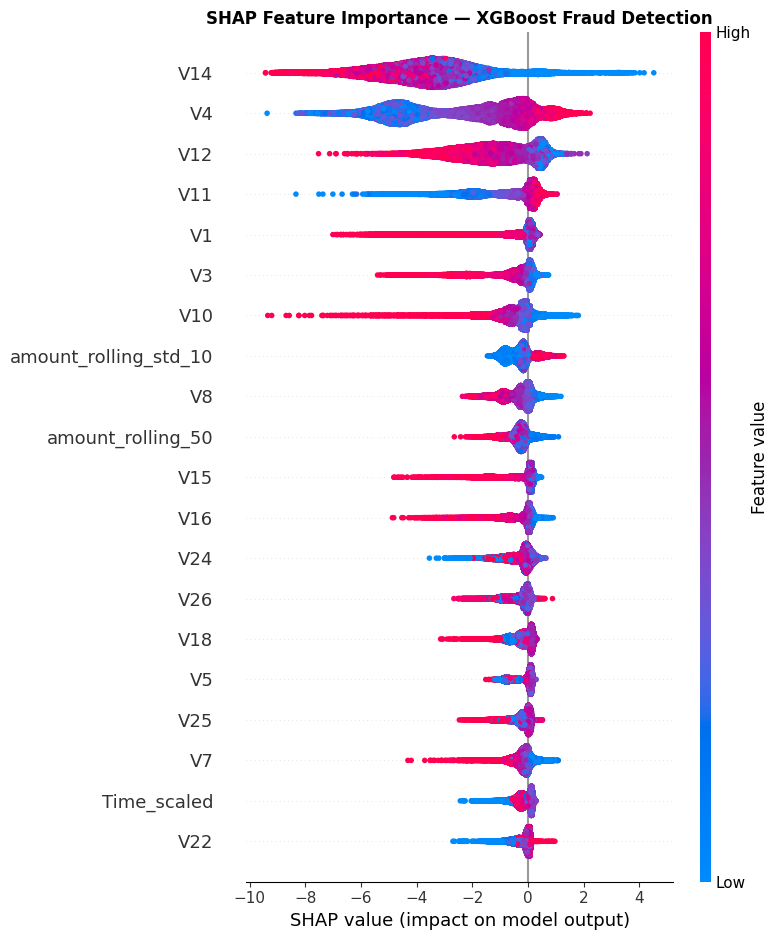

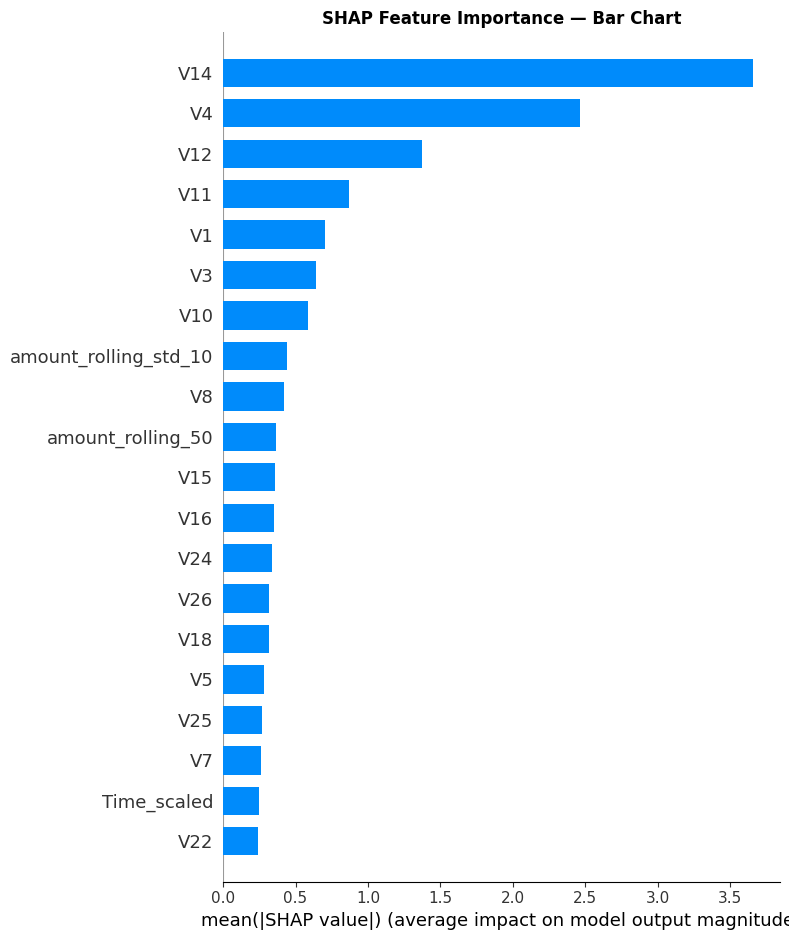

✅ SHAP plots saved


In [5]:
print("Calculating SHAP values (this takes ~2 mins)...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("SHAP Feature Importance — XGBoost Fraud Detection", fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, 
                  plot_type='bar', show=False)
plt.title("SHAP Feature Importance — Bar Chart", fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_fraud_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plots saved")